# 5. MODIS greenness, extracted again

Notebook 4 used the release's table of MODIS greenness at the sites. Here the same greenness is extracted from the MODIS archive through Google Earth Engine, under the rules that docs/design.md sets for the satellite check. The notebook asks three things:

- **Is the extraction right?** It is tested at one site against values worked out by hand.
- **Which dates does the release's table hold?** The release describes its indices as June to August means, and the file name of its site table says August.
- **Does the greenness result of notebook 4 depend on how the release built its table?**

The extraction needs the `satellite` dependencies, a Google Cloud project registered for Earth Engine and a sign-in on the computer (`earthengine authenticate`, then `earthengine set_project`). The first run sends 86 requests for all sites and takes about 15 minutes. Later runs read the saved tables.

- **Reads** `sites.csv` from `data/processed/`, the greenness and weather tables of the release, and MODIS reflectance (MCD43A4) from Earth Engine.
- **Writes** `modis_candidates.csv`, `modis_august_mean.csv` and `modis_jul_aug_median.csv` to `data/processed/`.

In [1]:
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mn_desertification import data, paths, trends
from mn_desertification import satellite as sat
from mn_desertification.rules import MAIN_YEARS
from mn_desertification.weather import weather_remainders

sat.connect()
modis_pixels = sat.modis_grid()   # the product's own pixel grid, so nothing is resampled
print("MODIS pixel size (m):", round(modis_pixels.nominalScale().getInfo(), 1))

site_info = pd.read_csv(paths.PROCESSED_DIR / "sites.csv")
print("Sites:", len(site_info))

MODIS pixel size (m): 463.3
Sites: 1488


## A test at one site

Earth Engine computes on Google's servers and returns small tables. The test asks for every daily value of 2015 at the pixel that holds site 63, works out the season from them with pandas, and compares it with what the package returns for the same site. The season of the rule runs from 1 July to 31 August, and a site's value is the median of the season in each pixel, averaged within 100 m of the plot.

Days: 365 | with a value: 354


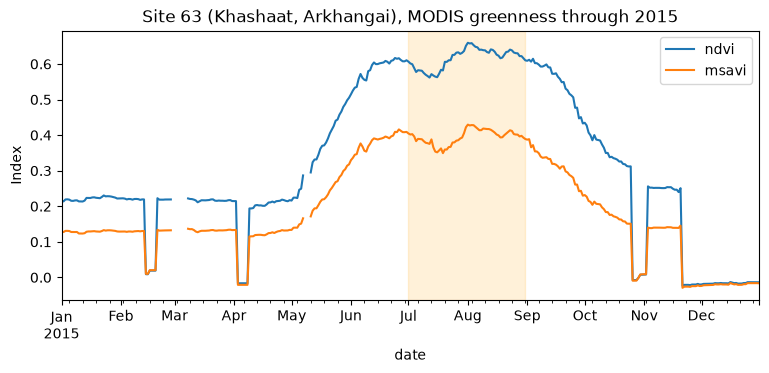

In [2]:
check = site_info[site_info["gid"] == 63].iloc[0]
days_2015 = sat.values_through_time(sat.modis_nbar("2015-01-01", "2016-01-01"), check["lon"], check["lat"], modis_pixels)
print("Days:", len(days_2015), "| with a value:", days_2015["ndvi"].notna().sum())

ax = days_2015.plot(x="date", y=["ndvi", "msavi"], figsize=(9, 3.5))
ax.axvspan(pd.Timestamp("2015-07-01"), pd.Timestamp("2015-08-31"), color="orange", alpha=0.15)
ax.set_ylabel("Index")
ax.set_title(f"Site 63 ({check['soum_eng']}, {check['aimag_eng']}), MODIS greenness through 2015")
plt.show()

In [3]:
# The season by hand, and from the package
season = days_2015[days_2015["date"].between("2015-07-01", "2015-08-31")]
print("By hand:  ndvi", round(season["ndvi"].median(), 4), "| msavi", round(season["msavi"].median(), 4),
      "| days with a value", season["ndvi"].notna().sum())

start, end = sat.season_dates(2015)   # Earth Engine leaves the end date out
print("Season:", start, "up to", end)
summer_2015 = sat.season_composite(sat.modis_nbar(start, end))
sat.values_at_sites(summer_2015, sat.site_footprints(site_info[site_info["gid"] == 63]), modis_pixels).round(4)

By hand:  ndvi 0.6255 | msavi 0.3971 | days with a value 62
Season: 2015-07-01 up to 2015-09-01


,gid,msavi,n_clear,ndvi
0,63,0.3971,62,0.6255


The package returns the by-hand value to four decimals. At site 63 the circle lies inside one pixel, so the mean within the circle is that pixel's median.

Most circles reach into a neighbouring pixel. Site 1 is one of them.

In [4]:
first = site_info[site_info["gid"] == 1].iloc[0]
value = sat.values_at_sites(summer_2015, sat.site_footprints(site_info[site_info["gid"] == 1]), modis_pixels)
print("Package, 100 m around site 1: ndvi", round(value["ndvi"].iloc[0], 4))

nearby = sat.pixels_near(summer_2015, first["lon"], first["lat"], modis_pixels, 500)
own, other = nearby["ndvi"].iloc[0], nearby["ndvi"].iloc[1]
print("Share of the plot's own pixel in that mean:", round((value["ndvi"].iloc[0] - other) / (own - other), 3))
nearby[["ndvi", "east_m", "north_m", "distance_m"]].round(3)

Package, 100 m around site 1: ndvi 0.502


Share of the plot's own pixel in that mean: 0.615


,ndvi,east_m,north_m,distance_m
0,0.482,-113.815,61.787,129.505
1,0.534,349.502,61.787,354.921
2,0.493,202.944,-401.525,449.899
3,0.447,-260.336,-401.525,478.537


- **The site's value is a mix of two pixels.** It lies between the plot's own pixel (0.482) and the next one to the east (0.534), with 61.5% of the weight on the plot's own.
- **The weights are approximate.** Earth Engine measures the share of each pixel inside the circle in steps of about 1/256 of a pixel. The share is the same in every year, so it cannot make a trend.
- **Neighbouring pixels differ.** The four pixels around this plot span 0.09 in NDVI. A MODIS pixel is a different piece of land from a clipping plot.

## Which dates does the release's table hold?

Three windows are extracted, each as a mean and as a median, with all values and with full inversions only, in three test years spread over the record. A full inversion is the better of the product's two kinds of fit. Each version is then set beside the release's values.

In [5]:
TEST_YEARS = [2002, 2012, 2022]
WINDOWS = {"June-August": ((6, 1), (8, 31)), "July-August": ((7, 1), (8, 31)), "August": ((8, 1), (8, 31))}
SOURCES = {"all": sat.modis_nbar, "full only": partial(sat.modis_nbar, full_inversions_only=True)}

footprints = sat.site_footprints(site_info)
candidates_file = paths.PROCESSED_DIR / "modis_candidates.csv"
if candidates_file.exists():
    candidates = pd.read_csv(candidates_file)
else:
    # 36 requests, about 10 minutes
    tables = []
    for quality, source in SOURCES.items():
        for window, (first_day, last_day) in WINDOWS.items():
            for how in ["mean", "median"]:
                table = sat.yearly_site_values(source, footprints, modis_pixels, TEST_YEARS, first_day, last_day, how)
                tables.append(table.assign(window=window, how=how, quality=quality))
                print("done:", quality, window, how)
    candidates = pd.concat(tables, ignore_index=True)
    candidates.to_csv(candidates_file, index=False)
print("Rows:", len(candidates), "| versions:", len(candidates.groupby(["quality", "window", "how"])),
      "| missing NDVI:", candidates["ndvi"].isna().sum())

Rows: 53568 | versions: 12 | missing NDVI: 10


In [6]:
release = data.read_greenness(indices=("ndvi", "msavi"))
compared = candidates.merge(release, on=["gid", "year"], suffixes=("", "_release"))
compared["gap"] = compared["ndvi"] - compared["ndvi_release"]   # this extraction minus the release

match_rows = []
for (quality, window, how), group in compared.groupby(["quality", "window", "how"], sort=False):
    match_rows.append({"quality": quality, "window": window, "how": how,
                       "correlation": group["ndvi"].corr(group["ndvi_release"]),
                       "mean abs gap": group["gap"].abs().mean(),
                       "mean gap": group["gap"].mean(),
                       "days per site": group["n_clear"].mean()})
pd.DataFrame(match_rows).round({"correlation": 4, "mean abs gap": 4, "mean gap": 4, "days per site": 1})

,quality,window,how,correlation,mean abs gap,mean gap,days per site
0,all,June-August,mean,0.9726,0.0383,-0.0304,91.9
1,all,June-August,median,0.9727,0.0330,-0.0221,91.9
2,all,July-August,mean,0.9875,0.0191,-0.0068,61.9
3,all,July-August,median,0.9886,0.0174,-0.0020,61.9
4,all,August,mean,0.9899,0.0172,0.0001,31.0
5,all,August,median,0.9890,0.0181,0.0032,31.0
6,full only,June-August,mean,0.9726,0.0377,-0.0299,87.6
7,full only,June-August,median,0.9726,0.0324,-0.0216,87.6
8,full only,July-August,mean,0.9880,0.0187,-0.0066,59.8
9,full only,July-August,median,0.9890,0.0169,-0.0016,59.8


- **June to August is ruled out.** Those versions lie 0.02 to 0.03 below the release. The release's site table is a late-summer value, as its file name says.
- **August and July to August are a tie.** The August mean has the highest correlation (0.9899) and no average gap. The July to August median with full inversions only has the smallest mean absolute gap (0.0169).
- **No version reproduces the table.** The closest still differ from it by 0.017 NDVI on average.
- **The quality filter hardly matters.** In July and August nearly all values come from full inversions, 59.8 of 61.9 days.

## Every year

Two versions are extracted for all 25 years. The August mean stands for the release's table. The July to August median is the rule of this study.

In [7]:
VERSIONS = {"august_mean": ((8, 1), (8, 31), "mean"),
            "jul_aug_median": ((7, 1), (8, 31), "median")}
modis = {}
for name, (first_day, last_day, how) in VERSIONS.items():
    file = paths.PROCESSED_DIR / f"modis_{name}.csv"
    if file.exists():
        modis[name] = pd.read_csv(file)
    else:
        # 25 requests each, about 5 minutes together
        modis[name] = sat.yearly_site_values(sat.modis_nbar, footprints, modis_pixels, range(2000, 2025), first_day, last_day, how)
        modis[name].to_csv(file, index=False)
    print(name, "| rows:", len(modis[name]), "| missing NDVI:", modis[name]["ndvi"].isna().sum(),
          "| fewest days at a site:", round(modis[name]["n_clear"].min(), 1))

august_mean | rows: 37200 | missing NDVI: 0 | fewest days at a site: 7.6
jul_aug_median | rows: 37200 | missing NDVI: 0 | fewest days at a site: 13.2


In [8]:
# Enough data? Sites with a value each year, and the days behind them, for the rule's version
by_year = modis["jul_aug_median"].groupby("year")
counts = pd.DataFrame({
    "sites with a value": by_year["ndvi"].count(),
    "median days": by_year["n_clear"].median(),
    "fewest days": by_year["n_clear"].min().round(1),
    "sites under 20 days": by_year["n_clear"].apply(lambda days: (days < 20).sum()),
})
pd.set_option("display.max_columns", 30)
counts.T

year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
sites with a value,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0
median days,58.0,62.0,62.0,62.0,62.0,62.0,62.0,62.0,62.0,62.0,62.0,62.0,62.0,62.0,62.0,62.0,62.0,62.0,62.0,62.0,62.0,62.0,62.0,58.0,62.0
fewest days,21.2,15.0,29.6,25.3,38.4,56.6,32.4,19.2,37.4,13.2,27.4,37.4,45.4,33.8,29.4,57.0,52.2,28.9,45.7,23.3,43.6,31.9,60.0,48.5,55.0
sites under 20 days,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
for name, table in modis.items():
    both = table.merge(release, on=["gid", "year"], suffixes=("", "_release"))
    gap = both["ndvi"] - both["ndvi_release"]
    print(f"{name}: correlation {both['ndvi'].corr(both['ndvi_release']):.4f} | mean abs gap {gap.abs().mean():.4f} | mean gap {gap.mean():+.4f}")

august_mean: correlation 0.9853 | mean abs gap 0.0213 | mean gap +0.0069
jul_aug_median: correlation 0.9864 | mean abs gap 0.0191 | mean gap -0.0033


Every site has a value in every year, and the median site has 58 to 62 days behind it. No year comes near the limits that the design sets for enough data. Over all 25 years the two versions correlate at 0.985 and 0.986 with the release's table.

## The greenness trends of notebook 4 again

The analysis of notebook 4 is repeated with the release's table and with each extracted version: greenness in logs, each site against its own average, with rain and summer temperature removed zone by zone.

In [10]:
weather = data.read_soum_weather()
trend_rows, yearly_means = [], {}
for name, table in {"release": release[["gid", "year", "ndvi"]], **modis}.items():
    table = table.merge(site_info[["gid", "asid"]], on="gid").merge(weather, on=["asid", "year"], how="left")
    for period, min_years in [(MAIN_YEARS, 8), ((2000, 2024), 20)]:
        remainders = weather_remainders(table[table["year"].between(*period)], "ndvi")
        trend, low, high = trends.mean_trend(remainders)
        tested = trends.site_trends(remainders, min_years=min_years)
        trend_rows.append({"version": name, "period": f"{period[0]}-{period[1]}",
                           "trend per decade": round(trend, 3), "95% range": f"{low:+.3f} to {high:+.3f}",
                           "sites tested": len(tested),
                           "sites declining": round((tested["p_decline"] < 0.05).mean(), 3)})
        if period == MAIN_YEARS:
            yearly_means[name] = trends.yearly_mean(remainders)
pd.DataFrame(trend_rows)

,version,period,trend per decade,95% range,sites tested,sites declining
0,release,2011-2020,0.001,-0.050 to +0.052,1487,0.050
1,release,2000-2024,0.033,+0.021 to +0.044,1486,0.007
2,august_mean,2011-2020,0.021,-0.041 to +0.084,1488,0.023
3,august_mean,2000-2024,0.037,+0.025 to +0.050,1488,0.003
4,jul_aug_median,2011-2020,-0.007,-0.057 to +0.043,1488,0.050
5,jul_aug_median,2000-2024,0.033,+0.020 to +0.045,1488,0.005


Correlation with the release's yearly means: {'release': 1.0, 'august_mean': 0.83, 'jul_aug_median': 0.84}


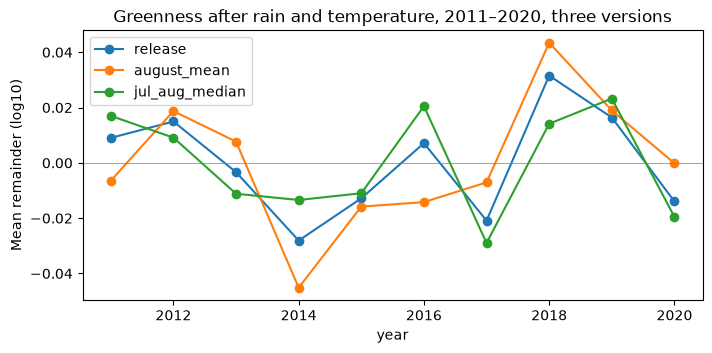

year,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
release,0.009,0.015,-0.003,-0.028,-0.013,0.007,-0.021,0.032,0.016,-0.014
august_mean,-0.006,0.019,0.008,-0.045,-0.016,-0.014,-0.007,0.043,0.019,-0.000
jul_aug_median,0.017,0.009,-0.011,-0.013,-0.011,0.021,-0.029,0.014,0.023,-0.020


In [11]:
yearly_means = pd.DataFrame(yearly_means)
print("Correlation with the release's yearly means:", yearly_means.corr()["release"].round(2).to_dict())

ax = yearly_means.plot(marker="o", figsize=(8, 3.5))
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_ylabel("Mean remainder (log10)")
ax.set_title("Greenness after rain and temperature, 2011–2020, three versions")
plt.show()
yearly_means.round(3).T

## In short

- **The extraction is right.** Where a site's circle lies inside one pixel, the package returns the value worked out by hand.
- **The release's site table is a late-summer value,** close to an August mean. It could not be reproduced exactly, and the cause of the remaining difference was not found.
- **The greenness result of notebook 4 does not depend on that.** In every version greenness is flat over 2011–2020, with a 95% range that spans zero and no more sites declining than chance gives, and it rises over 2000–2024.